# Lesson 07 - Autoencoders: compression, denoising, and PCA/SVD.


Questions this lesson answers
-----------------------------
* What does a bottleneck network learn when trained to copy its input?
* Is a *linear* autoencoder just PCA? (Same subspace, same optimal error - we check.)
* How much do non-linearity and convolutions buy for compression?
* How does a denoising autoencoder remove noise it has never seen the clean version of at test time?

Script version:  python lessons/07_autoencoders/lesson.py

## Lesson 07 - Autoencoders: compression, denoising, and PCA/SVD

📄 [`lessons/07_autoencoders/lesson.py`](../lessons/07_autoencoders/lesson.py) · 📓 [`notebooks/07_autoencoders.ipynb`](07_autoencoders.ipynb) · code: [`nnaz/autoencoder.py`](../nnaz/autoencoder.py)

### The idea

An autoencoder is an encoder $e:\mathbb R^D\to\mathbb R^k$ and a decoder $d:\mathbb R^k\to\mathbb R^D$,
trained to reproduce its input through a **bottleneck** $k\ll D$:

$$\min_{e,d}\ \frac1N\sum_n\lVert x_n-d(e(x_n))\rVert^2 .$$

The network cannot copy the input, so it must find a compact **code** that captures the
structure of the data. In engineering this is **model-order reduction**: the same idea compresses
CFD snapshots in lesson 16.

### A linear autoencoder *is* PCA, and we can check it exactly

Centre the data, $X-\bar x=U\Sigma V^\top$ (SVD). By the **Eckart-Young theorem**, the best
rank-$k$ approximation in the least-squares sense is the projection onto the first $k$ right
singular vectors, with error $\sum_{i>k}\sigma_i^2/N$. A linear autoencoder
$x\mapsto W_dW_ex$ is a rank-$k$ map, so it cannot beat this. Baldi and Hornik (1989) showed that
all its minima span **the same subspace** as $V_k$. But $W_d$ need not be orthonormal, so the
individual latent coordinates are an arbitrary invertible mixture of the principal components.
We measure both claims: the training MSE against the exact optimum, and the principal angles
between the column space of $W_d$ and $\operatorname{span}(V_k)$.

<p align="center"><img src="../docs/lesson07/pca_vs_linear_ae_basis.png" width="75%"></p>

### Non-linear and convolutional autoencoders

* **MLP autoencoder**: 784-256-$k$-256-784, ReLU, sigmoid output.
* **Convolutional autoencoder**: strided 3×3 convolutions downsample 28→14→7, a linear layer maps
  to the $k$-dimensional code, and **transposed convolutions** (learnable up-sampling) map back
  7→14→28. It has fewer parameters because of weight sharing (lesson 05).

<p align="center"><img src="../docs/lesson07/compression_vs_k.png" width="85%"><br><img src="../docs/lesson07/reconstructions.png" width="65%"></p>

*(see the results table in the README)*

*Note: the denoising row above still comes from the first (non-residual) denoiser, which barely beat the noisy input; the residual version described below is regenerated in the next full run.*

**Reading the table.**
* The linear AE reaches the Eckart-Young optimum to within 0.1-0.6 %, as theory says.
* The principal angles are small, but not zero, and they are **largest for $k=4$**. When two
  singular values are close ($\sigma_4\approx\sigma_5$), the optimal subspace is ill-conditioned:
  rotating inside the near-degenerate pair costs almost no loss. The angle error scales like
  (loss gap)/(eigenvalue gap). This is a general lesson for POD/PCA with clustered spectra.
* Non-linear autoencoders beat PCA at every $k$. At $k=16$ the MLP AE halves the error, because
  the digit manifold is curved and a linear subspace wastes dimensions.
* The convolutional AE is trained for **one third of the epochs** (it costs about 5× more per
  epoch on a CPU), so it is *not* a fair loss comparison. We report it as run.
* In 2-D the non-linear code separates the digit classes much better than the PCA plane
  (5-NN accuracy in the table).

<p align="center"><img src="../docs/lesson07/latent_2d.png" width="75%"></p>

### Denoising

Train with **corrupted inputs and clean targets**, $\min\lVert x-f(x+\eta)\rVert^2$ with
$\eta\sim\mathcal N(0,0.5^2)$. The network must learn what digits look like in order to remove
what does not belong. The baseline is **projection onto the top-$k$ principal components**,
which is classical linear denoising (we report the best $k$). Our denoiser is a small fully
convolutional network with **residual learning** (Zhang et al. 2017): it predicts the correction
$f(\tilde x)$ and outputs $\tilde x+f(\tilde x)$, starting from the identity map.

<p align="center"><img src="../docs/lesson07/denoising.png" width="65%"></p>



In [1]:
%matplotlib inline
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make `nnaz` importable
from nnaz.notebooks import show_new_figures

from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import torch
from nnaz.autoencoder import (ConvAE, DenoisingConvNet, LinearAE, MLPAE, pca_fit, pca_reconstruct,
                              principal_angles, psnr, reconstruct, train_ae)
from nnaz.common import banner, save_results, savefig, seed_everything, set_torch_threads, setup_matplotlib
from nnaz.data import load_mnist
LESSON = 7
plt = setup_matplotlib()
IMG = (1, 28, 28)

In [2]:
def load(quick):
    xtr, ytr = load_mnist("MNIST", True)
    xte, yte = load_mnist("MNIST", False)
    n = 10000 if quick else 60000
    Xtr = xtr[:n].reshape(n, -1).astype(np.float32) / 255
    Xte = xte[:2000].reshape(2000, -1).astype(np.float32) / 255
    return Xtr, Xte, yte[:2000]

## 1. PCA (exact, via SVD) vs a linear autoencoder vs a non-linear one

In [3]:
def pca_vs_linear_ae(Xtr, Xte, quick):
    banner("1. PCA (exact, via SVD) vs a linear autoencoder vs a non-linear one")
    mu, V, s = pca_fit(Xtr.astype(np.float64))
    N = len(Xtr)
    ks = [2, 4, 8, 16, 32]
    epochs = 3 if quick else 15
    rows = {}
    Xt, Xtest = torch.as_tensor(Xtr), torch.as_tensor(Xte)
    Xc = torch.as_tensor(Xtr - mu.astype(np.float32))  # the linear AE sees centred data
    for k in ks:
        pca_train = float((s[k:] ** 2).sum() / (N * Xtr.shape[1]))  # Eckart-Young optimum (per pixel)
        pca_test = float(((pca_reconstruct(Xte, mu, V, k) - Xte) ** 2).mean())
        torch.manual_seed(k)
        lin = LinearAE(784, k)
        train_ae(lin, Xc, epochs=epochs, lr=2e-3)
        lin_train = float(((reconstruct(lin, Xc) - Xc) ** 2).mean())
        lin_test = float(((reconstruct(lin, torch.as_tensor(Xte - mu.astype(np.float32))).numpy() + mu - Xte) ** 2).mean())
        ang = principal_angles(lin.dec.weight.detach().double().numpy(), V[:, :k])
        torch.manual_seed(k)
        mlp = MLPAE(784, k)
        train_ae(mlp, Xt, epochs=epochs)
        mlp_test = float(((reconstruct(mlp, Xtest) - Xtest) ** 2).mean())
        torch.manual_seed(k)
        conv = ConvAE(k)
        train_ae(conv, Xt, epochs=max(1, epochs // 3), shape=IMG)  # ~6 s/epoch: fewer epochs
        conv_test = float(((reconstruct(conv, Xtest, IMG) - Xtest) ** 2).mean())
        rows[k] = dict(pca_train_optimum=pca_train, linear_ae_train=lin_train, pca_test=pca_test,
                       linear_ae_test=lin_test, max_principal_angle_deg=float(np.degrees(ang.max())),
                       mlp_ae_test=mlp_test, conv_ae_test=conv_test)
        print(f"  k={k:2d}  train MSE: PCA optimum {pca_train:.5f}  linear AE {lin_train:.5f}"
              f" (gap {100 * (lin_train / pca_train - 1):.2f}%, max angle {np.degrees(ang.max()):.1f} deg)"
              f" | test MSE: PCA {pca_test:.5f}  MLP-AE {mlp_test:.5f}  conv-AE {conv_test:.5f}")
        if k == 16:
            models16 = (lin, mlp, conv)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
    axs[0].semilogy(ks, [rows[k]["pca_test"] for k in ks], "o-", label="PCA (SVD)")
    axs[0].semilogy(ks, [rows[k]["linear_ae_test"] for k in ks], "x--", ms=9, label="linear autoencoder")
    axs[0].semilogy(ks, [rows[k]["mlp_ae_test"] for k in ks], "s-", label="MLP autoencoder")
    axs[0].semilogy(ks, [rows[k]["conv_ae_test"] for k in ks], "^-", label="conv autoencoder")
    axs[0].set_xscale("log", base=2); axs[0].set_xlabel("bottleneck size k")
    axs[0].set_ylabel("test MSE per pixel"); axs[0].legend(); axs[0].set_title("compression error")
    energy = np.cumsum(s ** 2) / np.sum(s ** 2)
    axs[1].plot(np.arange(1, 101), energy[:100])
    axs[1].set_xlabel("number of principal components"); axs[1].set_ylabel("fraction of variance")
    axs[1].set_title("PCA spectrum of MNIST")
    savefig(fig, LESSON, "compression_vs_k.png")

    # reconstructions at k = 16
    lin, mlp, conv = models16
    n = 10
    recs = [Xte[:n], pca_reconstruct(Xte[:n], mu, V, 16),
            reconstruct(lin, torch.as_tensor(Xte[:n] - mu.astype(np.float32))).numpy() + mu,
            reconstruct(mlp, Xtest[:n]).numpy(), reconstruct(conv, Xtest[:n], IMG).numpy()]
    names = ["original", "PCA k=16", "linear AE k=16", "MLP AE k=16", "conv AE k=16"]
    fig, axs = plt.subplots(len(recs), n, figsize=(n * 0.9, len(recs) * 1.0))
    for r, (rec, nm) in enumerate(zip(recs, names)):
        for c in range(n):
            axs[r, c].imshow(np.clip(rec[c], 0, 1).reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
            axs[r, c].set_xticks([]); axs[r, c].set_yticks([]); axs[r, c].grid(False)
        axs[r, 0].set_ylabel(nm, rotation=0, ha="right", fontsize=8)
    savefig(fig, LESSON, "reconstructions.png")

    # the first principal components vs what the linear AE decoder learnt
    fig, axs = plt.subplots(2, 8, figsize=(9, 2.6))
    Wd = lin.dec.weight.detach().numpy()
    for i in range(8):
        for r, img in enumerate([V[:, i], Wd[:, i]]):
            v = np.abs(img).max()
            axs[r, i].imshow(img.reshape(28, 28), cmap="RdBu", vmin=-v, vmax=v)
            axs[r, i].set_xticks([]); axs[r, i].set_yticks([]); axs[r, i].grid(False)
    axs[0, 0].set_ylabel("PCs", fontsize=8); axs[1, 0].set_ylabel("lin. AE", fontsize=8)
    fig.suptitle("top: principal components; bottom: linear-AE decoder columns (same span, mixed basis)")
    savefig(fig, LESSON, "pca_vs_linear_ae_basis.png")
    return {"compression": rows}

## 2. A 2-D bottleneck: PCA plane vs non-linear autoencoder latent space

In [4]:
def latent_part(Xtr, Xte, yte, quick):
    banner("2. A 2-D bottleneck: PCA plane vs non-linear autoencoder latent space")
    mu, V, s = pca_fit(Xtr.astype(np.float64))
    Zp = (Xte - mu) @ V[:, :2]
    torch.manual_seed(0)
    ae = MLPAE(784, 2)
    train_ae(ae, torch.as_tensor(Xtr), epochs=3 if quick else 15)
    with torch.no_grad():
        Za = ae.enc(torch.as_tensor(Xte)).numpy()
    fig, axs = plt.subplots(1, 2, figsize=(10, 4.3))
    for ax, Z, t in [(axs[0], Zp, "PCA: first 2 components"), (axs[1], Za, "MLP autoencoder: 2-D code")]:
        sc = ax.scatter(Z[:, 0], Z[:, 1], c=yte, cmap="tab10", s=4)
        ax.set_title(t)
    fig.colorbar(sc, ax=axs, ticks=range(10), label="digit")
    savefig(fig, LESSON, "latent_2d.png")
    # a simple quantitative measure: k-NN (k=5) accuracy in the 2-D code
    def knn_acc(Z, y):
        D = ((Z[:, None] - Z[None]) ** 2).sum(-1)
        np.fill_diagonal(D, np.inf)
        nn5 = np.argsort(D, 1)[:, :5]
        pred = np.array([np.bincount(y[r], minlength=10).argmax() for r in nn5])
        return float((pred == y).mean())
    res = {"knn5_acc_pca2": knn_acc(Zp, yte), "knn5_acc_ae2": knn_acc(Za, yte)}
    print(f"  5-NN digit accuracy in the 2-D code: PCA {res['knn5_acc_pca2']:.3f}  autoencoder {res['knn5_acc_ae2']:.3f}")
    return res

## 3. Denoising: Gaussian noise sigma = 0.5 on [0,1] pixels

In [5]:
def denoising_part(Xtr, Xte, quick):
    banner("3. Denoising: Gaussian noise sigma = 0.5 on [0,1] pixels")
    sigma = 0.5
    g = torch.Generator().manual_seed(1)
    Xtest = torch.as_tensor(Xte)
    noisy = (Xtest + sigma * torch.randn(Xtest.shape, generator=g)).clamp(0, 1)
    mu, V, s = pca_fit(Xtr.astype(np.float64))
    res = {"psnr_noisy": psnr(noisy, Xte)}
    # PCA denoising: project the noisy image onto the top-k principal subspace
    best = max((psnr(pca_reconstruct(noisy.numpy(), mu, V, k), Xte), k) for k in (8, 16, 32, 64))
    res["psnr_pca_best"], res["pca_best_k"] = best
    torch.manual_seed(0)
    dae = DenoisingConvNet(c=16)
    train_ae(dae, torch.as_tensor(Xtr), epochs=1 if quick else 4, noise=sigma, shape=IMG)
    den = reconstruct(dae, noisy, IMG).numpy()
    res["psnr_conv_dae"] = psnr(den, Xte)
    print(f"  PSNR: noisy input {res['psnr_noisy']:.2f} dB | PCA projection (best k={res['pca_best_k']})"
          f" {res['psnr_pca_best']:.2f} dB | conv denoising AE {res['psnr_conv_dae']:.2f} dB")
    n = 10
    rows = [Xte[:n], noisy[:n].numpy(), pca_reconstruct(noisy[:n].numpy(), mu, V, res["pca_best_k"]), den[:n]]
    names = ["clean", "noisy (input)", f"PCA k={res['pca_best_k']}", "conv DAE"]
    fig, axs = plt.subplots(4, n, figsize=(n * 0.9, 4.0))
    for r, (rec, nm) in enumerate(zip(rows, names)):
        for c in range(n):
            axs[r, c].imshow(np.clip(rec[c], 0, 1).reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
            axs[r, c].set_xticks([]); axs[r, c].set_yticks([]); axs[r, c].grid(False)
        axs[r, 0].set_ylabel(nm, rotation=0, ha="right", fontsize=8)
    savefig(fig, LESSON, "denoising.png")
    return {"denoising": res}

## Run the lesson

Set `quick = True` for a fast pass (fewer epochs; numbers will differ from the README).

In [6]:
quick = False

In [7]:
seed_everything(7)

Generator(PCG64) at 0x7FC52E5133E0

In [8]:
set_torch_threads()

In [9]:
Xtr, Xte, yte = load(quick)

In [10]:
res = pca_vs_linear_ae(Xtr, Xte, quick)


1. PCA (exact, via SVD) vs a linear autoencoder vs a non-linear one


  k= 2  train MSE: PCA optimum 0.05595  linear AE 0.05605 (gap 0.17%, max angle 15.1 deg) | test MSE: PCA 0.05379  MLP-AE 0.04251  conv-AE 0.05037


  k= 4  train MSE: PCA optimum 0.04818  linear AE 0.04831 (gap 0.28%, max angle 32.0 deg) | test MSE: PCA 0.04683  MLP-AE 0.03121  conv-AE 0.03889


  k= 8  train MSE: PCA optimum 0.03787  linear AE 0.03790 (gap 0.10%, max angle 10.5 deg) | test MSE: PCA 0.03727  MLP-AE 0.02003  conv-AE 0.02479


  k=16  train MSE: PCA optimum 0.02729  linear AE 0.02736 (gap 0.24%, max angle 5.4 deg) | test MSE: PCA 0.02725  MLP-AE 0.01210  conv-AE 0.01564


  k=32  train MSE: PCA optimum 0.01724  linear AE 0.01735 (gap 0.63%, max angle 9.0 deg) | test MSE: PCA 0.01734  MLP-AE 0.00716  conv-AE 0.00821


  saved docs/lesson07/compression_vs_k.png


  saved docs/lesson07/reconstructions.png


  saved docs/lesson07/pca_vs_linear_ae_basis.png



2. A 2-D bottleneck: PCA plane vs non-linear autoencoder latent space


  saved docs/lesson07/latent_2d.png


  5-NN digit accuracy in the 2-D code: PCA 0.412  autoencoder 0.583


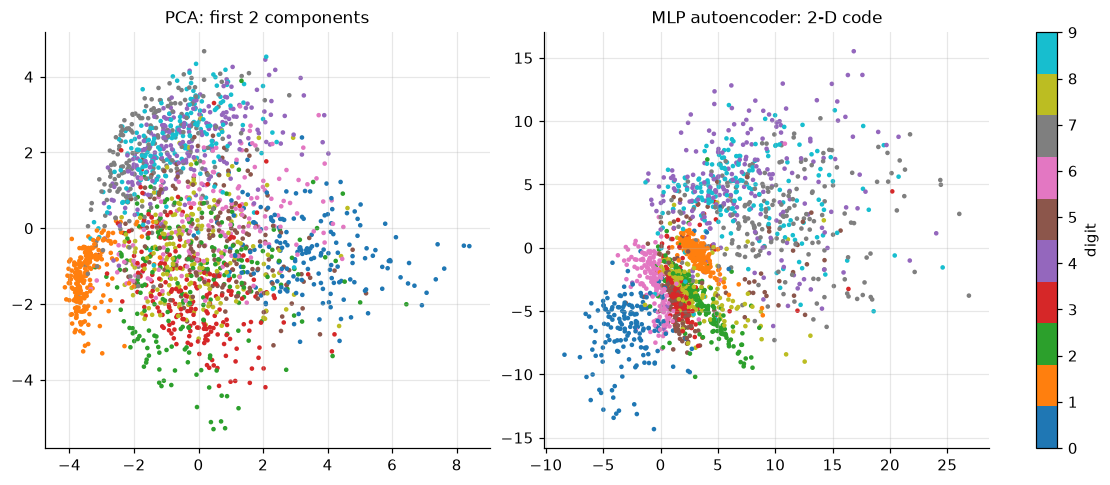

In [11]:
t0 = time.time()
res.update(latent_part(Xtr, Xte, yte, quick))
show_new_figures(t0, LESSON)


3. Denoising: Gaussian noise sigma = 0.5 on [0,1] pixels


  PSNR: noisy input 9.37 dB | PCA projection (best k=64) 15.09 dB | conv denoising AE 18.72 dB


  saved docs/lesson07/denoising.png


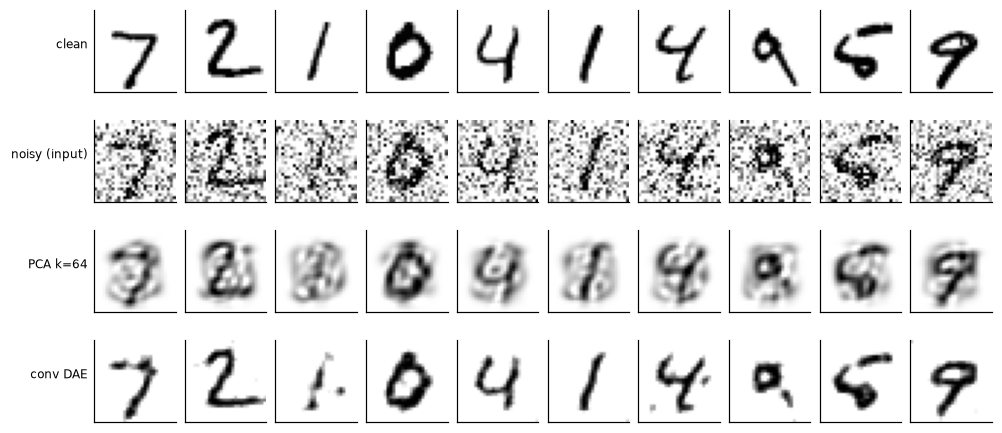

In [12]:
t0 = time.time()
res.update(denoising_part(Xtr, Xte, quick))
show_new_figures(t0, LESSON)

In [13]:
_ = save_results(LESSON, res)

In [14]:
res  # all numbers of this run

{'compression': {2: {'pca_train_optimum': 0.05595270364213884,
   'linear_ae_train': 0.05604877322912216,
   'pca_test': 0.05378600350191109,
   'linear_ae_test': 0.053973991056822344,
   'max_principal_angle_deg': 15.069828591354863,
   'mlp_ae_test': 0.04251351207494736,
   'conv_ae_test': 0.05037164315581322},
  4: {'pca_train_optimum': 0.04817945409387748,
   'linear_ae_train': 0.048314422369003296,
   'pca_test': 0.04683138436465741,
   'linear_ae_test': 0.04703965904736633,
   'max_principal_angle_deg': 31.982170276994058,
   'mlp_ae_test': 0.031206639483571053,
   'conv_ae_test': 0.03889063373208046},
  8: {'pca_train_optimum': 0.03786521729268965,
   'linear_ae_train': 0.03790360689163208,
   'pca_test': 0.037273923820863704,
   'linear_ae_test': 0.037297207796323895,
   'max_principal_angle_deg': 10.512485375501113,
   'mlp_ae_test': 0.020028751343488693,
   'conv_ae_test': 0.024785198271274567},
  16: {'pca_train_optimum': 0.027292815829186648,
   'linear_ae_train': 0.0273579